In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import missingno as ms
from sklearn.metrics import precision_score,recall_score,f1_score
%matplotlib inline

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
data = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')

In [3]:
data.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [4]:
data.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


In [5]:
data.shape

(8693, 14)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [8]:
data.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

<Axes: >

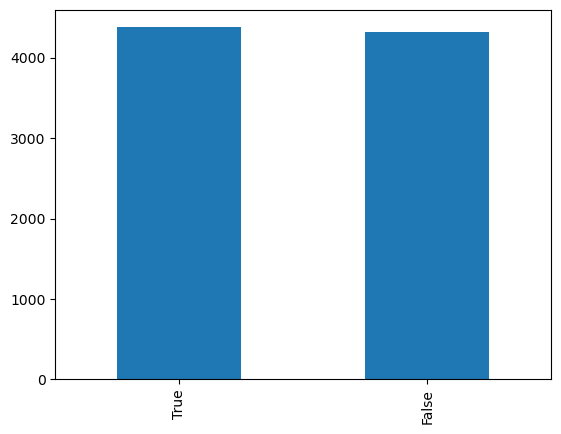

In [9]:
data['Transported'].value_counts().plot(kind='bar')

In [10]:
le=LabelEncoder()
data['Transported']=le.fit_transform(data['Transported'])
data['HomePlanet']=le.fit_transform(data['HomePlanet'])
data['Destination']=le.fit_transform(data['Destination'])
data['VIP']=le.fit_transform(data['VIP'])
data['CryoSleep']=le.fit_transform(data['CryoSleep'])


In [11]:
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,1,0,B/0/P,2,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
1,0002_01,0,0,F/0/S,2,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,1,0,A/0/S,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,1,0,A/0/S,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
4,0004_01,0,0,F/1/S,2,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1


In [12]:
a = data['Age']

In [13]:
data['Age'] = data['Age'].fillna(a.mean())

In [14]:
data.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age               0
VIP               0
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [15]:
data = data.dropna()

In [16]:

data.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [17]:
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,1,0,B/0/P,2,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
1,0002_01,0,0,F/0/S,2,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,1,0,A/0/S,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,1,0,A/0/S,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
4,0004_01,0,0,F/1/S,2,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1


In [18]:
data["PassengerId"] = data["PassengerId"].astype(int)

In [19]:
corr=data.corr()

/tmp/ipykernel_20/2057684327.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr=data.corr()


In [20]:
corr

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
PassengerId,1.000000,-0.002176,-0.002857,-0.008453,-0.009104,0.018346,0.002994,-0.009773,0.019312,-0.008091,0.006928,0.016463
HomePlanet,-0.002176,1.000000,0.065055,0.045728,0.125670,0.043582,0.198488,0.056056,0.095033,0.045725,0.035462,0.100923
CryoSleep,-0.002857,0.065055,1.000000,-0.091925,-0.069517,-0.024977,-0.222263,-0.182122,-0.205494,-0.176578,-0.179730,0.403305
Destination,-0.008453,0.045728,-0.091925,1.000000,-0.006515,-0.024965,0.051260,-0.113552,0.016546,-0.056056,-0.069148,-0.120521
Age,-0.009104,0.125670,-0.069517,-0.006515,1.000000,0.031905,0.071593,0.130666,0.042362,0.122389,0.104200,-0.080361
VIP,0.018346,0.043582,-0.024977,-0.024965,0.031905,1.000000,0.022249,0.059290,-0.015918,0.020964,0.058331,-0.013850
RoomService,0.002994,0.198488,-0.222263,0.051260,0.071593,0.022249,1.000000,-0.018107,0.061979,0.015047,-0.023024,-0.247911
FoodCourt,-0.009773,0.056056,-0.182122,-0.113552,0.130666,0.059290,-0.018107,1.000000,-0.012555,0.212349,0.218410,0.054430
ShoppingMall,0.019312,0.095033,-0.205494,0.016546,0.042362,-0.015918,0.061979,-0.012555,1.000000,0.021141,-0.002225,0.006165
Spa,-0.008091,0.045725,-0.176578,-0.056056,0.122389,0.020964,0.015047,0.212349,0.021141,1.000000,0.148909,-0.221139


<Axes: >

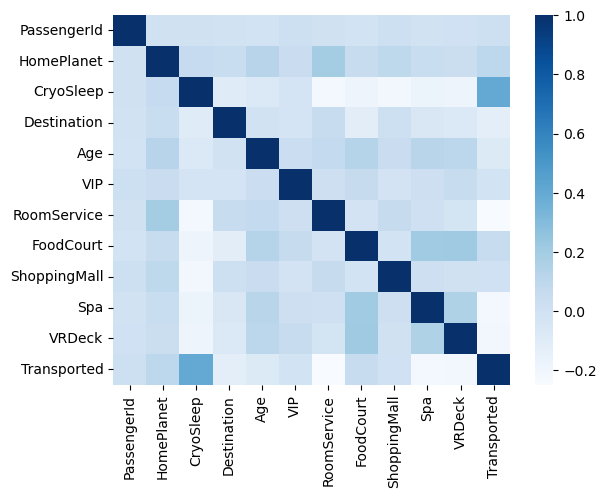

In [21]:
sns.heatmap(corr,cmap='Blues')

In [22]:
print(data.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')


In [23]:
data=data.drop('Cabin',axis=1)

In [24]:
X=data.iloc[:,0:11]

In [25]:
X

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,101,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0
1,201,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0
2,301,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0
3,302,1,0,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0
4,401,0,0,2,16.0,0,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
8688,927601,1,0,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0
8689,927801,0,1,1,18.0,0,0.0,0.0,0.0,0.0,0.0
8690,927901,0,0,2,26.0,0,0.0,0.0,1872.0,1.0,0.0
8691,928001,1,0,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0


In [26]:
y=data.iloc[:,-1]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=60)

In [28]:
X_test

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
1144,121104,0,1,2,3.0,0,0.0,0.0,0.0,0.0,0.0
1966,209901,2,0,3,45.0,0,10.0,1095.0,1474.0,0.0,0.0
975,103401,0,0,2,31.0,0,0.0,0.0,0.0,675.0,213.0
805,85001,2,1,2,54.0,0,0.0,0.0,0.0,0.0,0.0
5250,560201,1,1,2,35.0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
3005,325501,0,1,1,20.0,0,0.0,0.0,0.0,0.0,0.0
7161,764301,1,0,0,53.0,0,8.0,1489.0,0.0,2723.0,7401.0
1883,200903,1,1,0,40.0,0,0.0,0.0,0.0,0.0,0.0
5010,535302,1,0,2,39.0,0,43.0,9365.0,144.0,0.0,118.0


In [29]:
!pip install catboost

In [30]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

# Define the CatBoost classifier and train the model
model = CatBoostClassifier(iterations=170, learning_rate=0.1, depth=7, loss_function='Logloss')
model.fit(X_train, y_train, verbose=False)

y_pred=model.predict(X_test)
# Evaluate the model on the testing set
accuracy = model.score(X_test, y_test)
print('Accuracy: {:.2f}%'.format(accuracy * 100))

Accuracy: 82.42%


In [31]:
print(confusion_matrix(y_test, y_pred))

[[606 155]
 [106 618]]


In [32]:
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.7994825355756792
0.8535911602209945
0.8256513026052104


In [33]:
test=pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [34]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [35]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [36]:
test=test.drop('Cabin',axis=1)
test=test.drop('Name',axis=1)

In [37]:
test['HomePlanet']=le.fit_transform(test['HomePlanet'])
test['Destination']=le.fit_transform(test['Destination'])
test['VIP']=le.fit_transform(test['VIP'])
test['CryoSleep']=le.fit_transform(test['CryoSleep'])

In [38]:
test=test.fillna(test.mean())

In [39]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0013_01,0,1,2,27.0,0,0.0,0.0,0.0,0.0,0.0
1,0018_01,0,0,2,19.0,0,0.0,9.0,0.0,2823.0,0.0
2,0019_01,1,1,0,31.0,0,0.0,0.0,0.0,0.0,0.0
3,0021_01,1,0,2,38.0,0,0.0,6652.0,0.0,181.0,585.0
4,0023_01,0,0,2,20.0,0,10.0,0.0,635.0,0.0,0.0


In [40]:
b=test['PassengerId']

In [41]:
test.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

In [42]:
test.shape

(4277, 11)

In [43]:
test["PassengerId"] = test["PassengerId"].astype(int)

In [44]:
test_pred = model.predict(test)

In [45]:
test_pred

array([1, 0, 1, ..., 1, 1, 1])

In [46]:
a=test_pred
# b=test['PassengerId']
final_df=pd.DataFrame({'PassengerID':b,'Transported':a})

final_df['Transported']=final_df['Transported'].replace({1: True, 0: False})
final_df

,PassengerID,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


In [47]:
final_df.to_csv("tit_submission.csv", index=False)